# Checkpoint 02 — Classificação e Regressão

Este notebook resolve as duas tarefas propostas:

1. **Classificação da fonte renovável** usando dados do SIGA/ANEEL.
2. **Regressão da radiação solar** usando dados históricos da API Open-Meteo para Petrolina (PE).

Os CSVs usados no trabalho ficam na mesma pasta do notebook. A seção de APIs contém o código para reproduzir os CSVs, mas a execução principal usa os arquivos já fornecidos para tornar o notebook reproduzível sem depender de conexão externa.

In [ ]:
# Imports
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, mean_absolute_error, mean_squared_error, r2_score
)

RANDOM_STATE = 42
pd.set_option("display.max_columns", None)


## 1. Reprodução dos dados pelas APIs

Os endpoints abaixo reproduzem os arquivos usados no trabalho. A célula está definida com `GERAR_CSVS = False` para que o notebook rode diretamente com os CSVs já incluídos no repositório. Para consultar novamente as APIs, altere para `True`.

- ANEEL/SIGA: cadastro de empreendimentos de geração.
- Open-Meteo Historical Weather API: dados horários de Petrolina entre 01/04/2025 e 30/06/2025.

In [ ]:
# Reprodução opcional dos CSVs a partir das APIs
GERAR_CSVS = False

if GERAR_CSVS:
    # ---------- ANEEL / SIGA ----------
    aneel_url = (
        "https://dadosabertos.aneel.gov.br/dataset/"
        "6d90b77c-c5f5-4d81-bdec-7bc619494bb9/resource/"
        "11ec447d-698d-4ab8-977f-b424d5deee6a/download/"
        "siga-empreendimentos-geracao.csv"
    )
    raw = pd.read_csv(aneel_url, low_memory=False)

    grupos = {
        "Solar": ["UFV"],
        "Eólica": ["EOL"],
        "Hidráulica": ["UHE", "PCH", "CGH"]
    }
    mapa = {sigla: classe for classe, siglas in grupos.items() for sigla in siglas}

    aneel = raw.copy()
    aneel["fonte"] = aneel["SigTipoGeracao"].map(mapa)
    aneel = aneel.rename(columns={
        "MdaPotenciaOutorgadaKw": "potencia_kw",
        "NumCoordNEmpreendimento": "latitude",
        "NumCoordEEmpreendimento": "longitude"
    })
    aneel = aneel[["potencia_kw", "latitude", "longitude", "fonte"]].copy()
    aneel = aneel.dropna()
    aneel["potencia_kw"] = pd.to_numeric(aneel["potencia_kw"], errors="coerce")
    aneel["latitude"] = pd.to_numeric(aneel["latitude"], errors="coerce")
    aneel["longitude"] = pd.to_numeric(aneel["longitude"], errors="coerce")
    aneel = aneel.dropna()
    aneel.to_csv("aneel_classificacao_orange.csv", index=False)

    # ---------- Open-Meteo ----------
    params = {
        "latitude": -9.39,
        "longitude": -40.50,
        "start_date": "2025-04-01",
        "end_date": "2025-06-30",
        "hourly": ",".join([
            "temperature_2m", "relative_humidity_2m", "cloud_cover",
            "wind_speed_10m", "shortwave_radiation"
        ]),
        "timezone": "America/Recife",
        "wind_speed_unit": "kmh"
    }
    response = requests.get(
        "https://archive-api.open-meteo.com/v1/archive",
        params=params,
        timeout=60
    )
    response.raise_for_status()
    data = response.json()["hourly"]

    meteo = pd.DataFrame(data)
    meteo = meteo.rename(columns={
        "time": "data_hora",
        "temperature_2m": "temperatura_c",
        "relative_humidity_2m": "umidade_pct",
        "cloud_cover": "nuvens_pct",
        "wind_speed_10m": "vento_kmh",
        "shortwave_radiation": "radiacao_w_m2"
    })
    meteo["data_hora"] = pd.to_datetime(meteo["data_hora"])
    meteo["hora"] = meteo["data_hora"].dt.hour
    meteo = meteo[meteo["hora"].between(7, 17)].copy()
    meteo = meteo[[
        "data_hora", "temperatura_c", "umidade_pct", "nuvens_pct",
        "vento_kmh", "hora", "radiacao_w_m2"
    ]]
    meteo.to_csv("meteo_regressao_orange.csv", index=False)

    print("CSVs regenerados com sucesso.")
else:
    print("GERAR_CSVS=False: usando os CSVs já presentes no repositório.")


GERAR_CSVS=False: usando os CSVs já presentes no repositório.


# Tarefa 1 — Classificação da fonte renovável

A variável-alvo é `fonte`. As entradas permitidas são somente `potencia_kw`, `latitude` e `longitude`. Não são usados nome, CEG, sigla ou qualquer descrição que entregue a classe.

In [ ]:
aneel = pd.read_csv("aneel_classificacao_orange.csv")

print("Dimensões:", aneel.shape)
display(aneel.head())
print("\nValores ausentes:")
display(aneel.isna().sum().to_frame("ausentes"))
print("\nDistribuição das classes:")
display(aneel["fonte"].value_counts().to_frame("quantidade"))


Dimensões: (3876, 4)


,potencia_kw,latitude,longitude,fonte
0,20.48,-10.442778,-64.151944,Solar
1,5000.00,-6.003889,-40.274722,Solar
2,12.26,-23.557778,-46.734000,Solar
3,3.00,-23.558889,-46.735000,Solar
4,1.70,-23.493819,-46.845000,Solar



Valores ausentes:


,ausentes
potencia_kw,0
latitude,0
longitude,0
fonte,0



Distribuição das classes:


,quantidade
fonte,
Hidráulica,1476
Solar,1200
Eólica,1200


Estatísticas das entradas:


,count,mean,std,min,25%,50%,75%,max
potencia_kw,3876.0,42014.681517,301636.587843,0.160000,440.000000,12680.000000,30000.000000,1.123310e+07
latitude,3876.0,-12.693951,9.500523,-33.722806,-21.142110,-10.469532,-4.127788,3.831392e+00
longitude,3876.0,-46.158299,8.357453,-69.941389,-52.561817,-47.393697,-41.280013,0.000000e+00


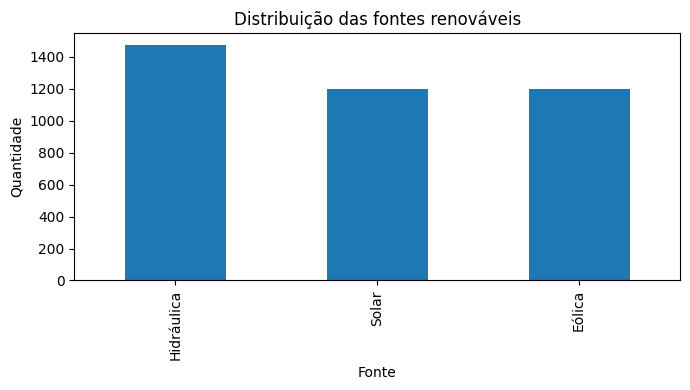

In [ ]:
print("Estatísticas das entradas:")
display(aneel[["potencia_kw", "latitude", "longitude"]].describe().T)

fig, ax = plt.subplots(figsize=(7, 4))
aneel["fonte"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Distribuição das fontes renováveis")
ax.set_xlabel("Fonte")
ax.set_ylabel("Quantidade")
plt.tight_layout()
plt.show()


In [ ]:
X = aneel[["potencia_kw", "latitude", "longitude"]]
y = aneel["fonte"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    stratify=y,
    random_state=RANDOM_STATE
)

print("Treino:", X_train.shape, "| Teste:", X_test.shape)
print("Proporções no treino:")
display(y_train.value_counts(normalize=True).round(3).to_frame("proporção"))


Treino: (3100, 3) | Teste: (776, 3)
Proporções no treino:


,proporção
fonte,
Hidráulica,0.381
Solar,0.310
Eólica,0.310


In [ ]:
classifiers = {
    "Regressão Logística": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))
    ]),
    "Random Forest": RandomForestClassifier(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "SVM (RBF)": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(kernel="rbf", random_state=RANDOM_STATE))
    ])
}

class_results = []
class_confusion = {}
class_labels = ["Eólica", "Hidráulica", "Solar"]

for name, model in classifiers.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    class_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision (macro)": precision_score(y_test, pred, average="macro"),
        "Recall (macro)": recall_score(y_test, pred, average="macro"),
        "F1 (macro)": f1_score(y_test, pred, average="macro")
    })
    class_confusion[name] = confusion_matrix(y_test, pred, labels=class_labels)

class_results_df = pd.DataFrame(class_results).set_index("Modelo")
display(class_results_df.round(4))
print("Média usada nas métricas multiclasses: MACRO (mesmo peso para cada classe).")


,Accuracy,Precision (macro),Recall (macro),F1 (macro)
Modelo,,,,
Regressão Logística,0.8247,0.8282,0.8214,0.8197
Random Forest,0.9755,0.9769,0.9741,0.9753
SVM (RBF),0.8634,0.8689,0.8599,0.8568


Média usada nas métricas multiclasses: MACRO (mesmo peso para cada classe).


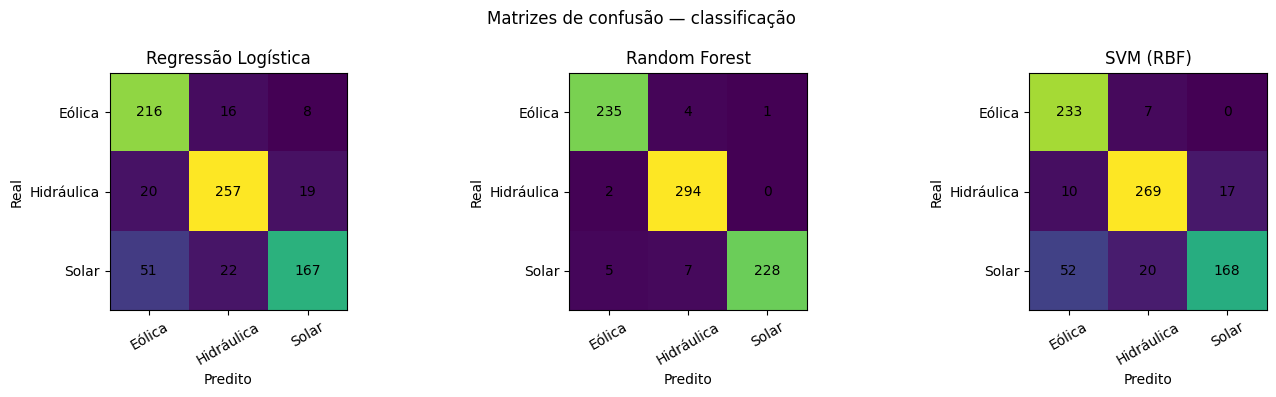

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, cm) in zip(axes, class_confusion.items()):
    im = ax.imshow(cm)
    ax.set_title(name)
    ax.set_xlabel("Predito")
    ax.set_ylabel("Real")
    ax.set_xticks(range(3), class_labels, rotation=30)
    ax.set_yticks(range(3), class_labels)
    for i in range(3):
        for j in range(3):
            ax.text(j, i, cm[i, j], ha="center", va="center")
fig.suptitle("Matrizes de confusão — classificação")
plt.tight_layout()
plt.show()


### Interpretação — classificação

A **Random Forest** apresenta o melhor desempenho entre os três modelos. As maiores confusões aparecem principalmente entre classes com características geográficas e faixas de potência que se sobrepõem. Isso mostra uma limitação importante: **potência e localização não carregam toda a informação física/administrativa necessária para identificar a fonte**.

Além disso, a base é um cadastro de empreendimentos, não uma medição de energia gerada. A potência outorgada não representa produção elétrica, e a localização sozinha não determina a tecnologia instalada. Portanto, mesmo um modelo com alta acurácia não deve ser interpretado como um classificador universal da fonte de geração.

# Tarefa 2 — Regressão da radiação solar

O alvo é `radiacao_w_m2`. A coluna `data_hora` serve para ordenar e separar os dados, mas não entra diretamente no modelo. O conjunto de teste corresponde às **últimas 20% das horas**, preservando a ordem temporal.

In [ ]:
meteo = pd.read_csv("meteo_regressao_orange.csv", parse_dates=["data_hora"])
meteo = meteo.sort_values("data_hora").reset_index(drop=True)

print("Dimensões:", meteo.shape)
display(meteo.head())
print("\nValores ausentes:")
display(meteo.isna().sum().to_frame("ausentes"))
print("\nResumo estatístico:")
display(meteo.describe().T)


Dimensões: (1001, 7)


,data_hora,temperatura_c,umidade_pct,nuvens_pct,vento_kmh,hora,radiacao_w_m2
0,2025-04-01 07:00:00,25.3,74,100,17.7,7,116.0
1,2025-04-01 08:00:00,26.5,66,100,18.1,8,269.0
2,2025-04-01 09:00:00,28.4,55,97,18.0,9,529.0
3,2025-04-01 10:00:00,30.8,44,21,18.4,10,797.0
4,2025-04-01 11:00:00,32.7,36,26,20.1,11,880.0



Valores ausentes:


,ausentes
data_hora,0
temperatura_c,0
umidade_pct,0
nuvens_pct,0
vento_kmh,0
hora,0
radiacao_w_m2,0



Resumo estatístico:


,count,mean,min,25%,50%,75%,max,std
data_hora,1001,2025-05-16 11:59:59.999999744,2025-04-01 07:00:00,2025-04-23 15:00:00,2025-05-16 12:00:00,2025-06-08 09:00:00,2025-06-30 17:00:00,NaN
temperatura_c,1001.0,28.885914,19.5,26.3,29.1,31.7,36.1,3.656514
umidade_pct,1001.0,50.544456,21.0,38.0,49.0,61.0,95.0,15.913965
nuvens_pct,1001.0,55.108891,0.0,19.0,54.0,98.0,100.0,37.851461
vento_kmh,1001.0,15.465435,2.3,12.2,15.4,19.0,30.1,4.923631
hora,1001.0,12.0,7.0,9.0,12.0,15.0,17.0,3.163858
radiacao_w_m2,1001.0,472.854146,13.0,250.0,466.0,696.0,1002.0,256.36895


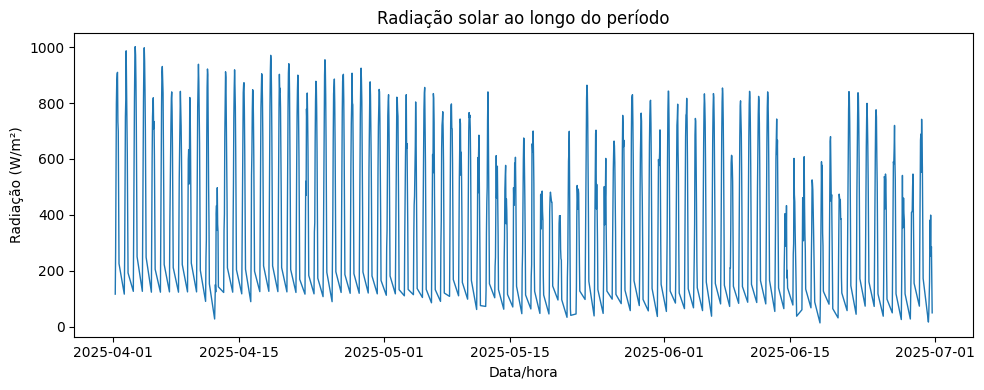

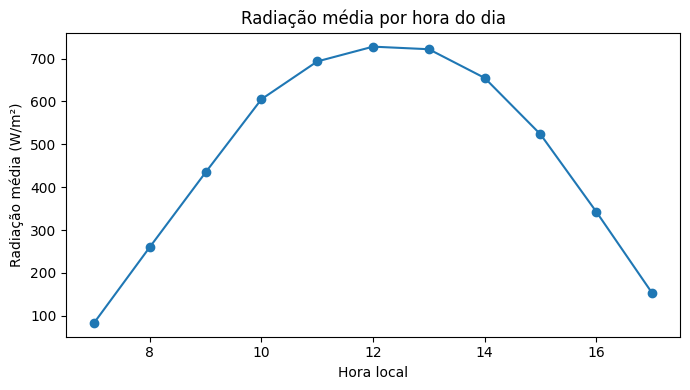

In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(meteo["data_hora"], meteo["radiacao_w_m2"], linewidth=1)
ax.set_title("Radiação solar ao longo do período")
ax.set_xlabel("Data/hora")
ax.set_ylabel("Radiação (W/m²)")
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(7, 4))
meteo.groupby("hora")["radiacao_w_m2"].mean().plot(marker="o", ax=ax)
ax.set_title("Radiação média por hora do dia")
ax.set_xlabel("Hora local")
ax.set_ylabel("Radiação média (W/m²)")
plt.tight_layout()
plt.show()


In [ ]:
features = ["temperatura_c", "umidade_pct", "nuvens_pct", "vento_kmh", "hora"]
X_reg = meteo[features]
y_reg = meteo["radiacao_w_m2"]

cut = int(len(meteo) * 0.80)

X_train_r = X_reg.iloc[:cut]
X_test_r = X_reg.iloc[cut:]
y_train_r = y_reg.iloc[:cut]
y_test_r = y_reg.iloc[cut:]

print(f"Treino: {len(X_train_r)} linhas | Teste: {len(X_test_r)} linhas")
print("Período de treino:", meteo["data_hora"].iloc[0], "até", meteo["data_hora"].iloc[cut-1])
print("Período de teste:", meteo["data_hora"].iloc[cut], "até", meteo["data_hora"].iloc[-1])


Treino: 800 linhas | Teste: 201 linhas
Período de treino: 2025-04-01 07:00:00 até 2025-06-12 14:00:00
Período de teste: 2025-06-12 15:00:00 até 2025-06-30 17:00:00


In [ ]:
regressors = {
    "Regressão Linear": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LinearRegression())
    ]),
    "Random Forest": RandomForestRegressor(
        n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=200, learning_rate=0.05, max_depth=3,
        random_state=RANDOM_STATE
    )
}

reg_results = []
reg_predictions = {}

for name, model in regressors.items():
    model.fit(X_train_r, y_train_r)
    pred = model.predict(X_test_r)
    reg_predictions[name] = pred

    reg_results.append({
        "Modelo": name,
        "MAE (W/m²)": mean_absolute_error(y_test_r, pred),
        "MSE ((W/m²)²)": mean_squared_error(y_test_r, pred),
        "R²": r2_score(y_test_r, pred)
    })

reg_results_df = pd.DataFrame(reg_results).set_index("Modelo")
display(reg_results_df.round(4))


,MAE (W/m²),MSE ((W/m²)²),R²
Modelo,,,
Regressão Linear,145.2049,30034.2011,0.3598
Random Forest,66.3994,7210.0838,0.8463
Gradient Boosting,66.7341,7373.9345,0.8428


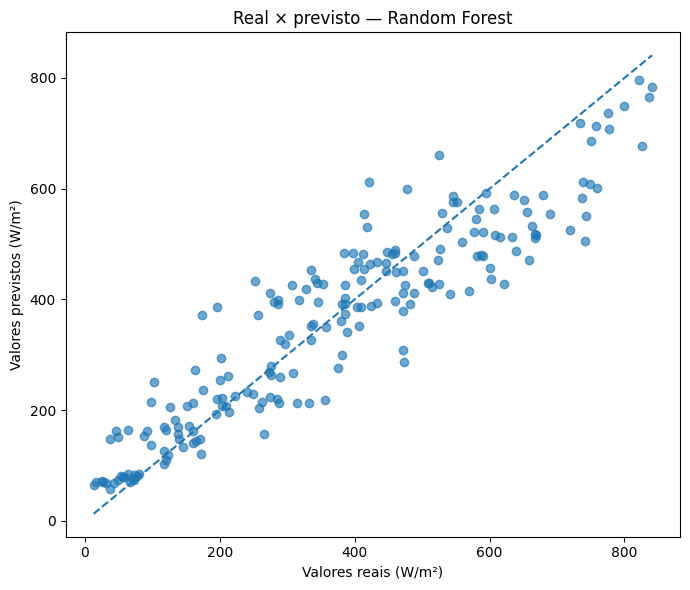

Modelo destacado no gráfico: Random Forest


In [ ]:
best_model = reg_results_df["MAE (W/m²)"].idxmin()
best_pred = reg_predictions[best_model]

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_test_r, best_pred, alpha=0.65)
lims = [
    min(y_test_r.min(), best_pred.min()),
    max(y_test_r.max(), best_pred.max())
]
ax.plot(lims, lims, linestyle="--")
ax.set_xlabel("Valores reais (W/m²)")
ax.set_ylabel("Valores previstos (W/m²)")
ax.set_title(f"Real × previsto — {best_model}")
plt.tight_layout()
plt.show()

print("Modelo destacado no gráfico:", best_model)


### Interpretação — regressão

A **hora do dia** é uma variável importante porque a radiação solar varia fortemente com a posição aparente do Sol: tende a ser menor pela manhã, aumenta até próximo do meio do dia e volta a cair à tarde. Nuvens também alteram diretamente a radiação que chega à superfície.

O melhor resultado foi obtido pela **Random Forest**, com desempenho superior à regressão linear e muito próximo do Gradient Boosting.

Por fim, **estimar radiação solar não é o mesmo que prever geração elétrica**. A radiação é uma condição física disponível no local, enquanto a geração depende também da potência instalada, área e tecnologia dos módulos, orientação/inclinação, eficiência, temperatura dos módulos, perdas, inversores, disponibilidade e outros fatores. Além disso, estes dados históricos são estimativas de reanálise/modelos meteorológicos, e não medições de um painel fotovoltaico.

## Conclusão

Nas duas tarefas, os modelos foram comparados usando a mesma divisão de dados entre os algoritmos.

- **Classificação:** Random Forest foi o melhor modelo nos dados de teste.
- **Regressão:** Random Forest apresentou o menor MAE e melhor R² entre os três modelos.
- A classificação é limitada porque fonte, potência e localização podem se sobrepor.
- A regressão captura padrões da radiação, especialmente associados à hora do dia e às condições meteorológicas, mas não deve ser interpretada como previsão direta da energia elétrica gerada.